In [1]:
import pandas as pd
import os
import datetime as dt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# !pip install TensorBoard 

In [5]:
# Set the random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
# df = pd.read_csv('dataset/X_train.csv').low_bnd.cumsum()
df = pd.read_csv(r'E:\working\pet-project\idea\aarhus\aarhus\dataset\dataset.csv', index_col=0, parse_dates=[0])

In [7]:
da = df.ActualSpotPrice.to_frame().pivot_table(values='ActualSpotPrice', 
                          index=df.reset_index()['index'].map(lambda x:x.date()).values, 
                          columns=df.reset_index()['index'].map(lambda x:x.hour).values,)

In [8]:
fp = df.ForecastedSpotPrice.to_frame().pivot_table(values='ForecastedSpotPrice', 
                          index=df.reset_index()['index'].map(lambda x:x.date()).values, 
                          columns=df.reset_index()['index'].map(lambda x:x.hour).values,)

In [9]:
display(da.head(2))
display(fp.head(2))

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
2021-11-01,29.94,51.81,43.92,22.05,20.36,41.82,58.29,77.54,88.81,85.59,...,79.56,84.26,87.39,93.85,92.52,84.2,79.92,76.42,72.05,70.59
2021-11-02,76.18,76.67,78.09,84.39,92.72,143.01,182.15,216.83,234.98,228.04,...,224.91,230.30,248.93,298.97,312.67,280.0,231.00,201.00,179.99,167.00


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
2021-11-01,72.81,72.36,69.27,66.03,70.23,70.64,88.04,96.20,96.20,94.01,...,81.19,84.55,87.82,94.01,94.1,91.04,89.94,87.37,86.56,77.67
2021-11-02,86.78,86.78,86.78,90.70,97.34,117.67,170.82,221.35,224.74,214.92,...,201.60,218.80,218.80,297.52,500.0,427.33,249.09,223.38,194.78,171.43


In [10]:
da.index.min(), da.index.max()

(datetime.date(2021, 11, 1), datetime.date(2024, 2, 20))

In [11]:
train = da.loc[:dt.date(2023, 12, 1)]
test = da.loc[dt.date(2023, 12, 1):]

In [12]:
train_f = fp.loc[:dt.date(2023, 12, 1)]
test_f = fp.loc[dt.date(2023, 12, 1):]

In [16]:
def plot_predictions_with_metrics(y_test, y_preds):
    # Calculate residuals
    residuals = y_test - y_preds

    # Calculate error metrics
    mse = mean_squared_error(y_test, y_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_preds)
    mae = mean_absolute_error(y_test, y_preds)
    mape = mean_absolute_percentage_error(y_test, y_preds)
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.subplots_adjust(hspace=0.4)

    # 1st subplot: Actual vs Predicted Values
    axes[0, 0].plot(y_test, label='Actual Values', color='blue', linestyle='-', linewidth=2)
    axes[0, 0].plot(y_preds, label='Predicted Values', color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Actual vs Predicted Values', fontsize=14)
    axes[0, 0].set_xlabel('Time Steps', fontsize=12)
    axes[0, 0].set_ylabel('Values', fontsize=12)
    axes[0, 0].legend(loc='best')
    axes[0, 0].grid(True)
    axes[0, 0].set_facecolor('#f2f2f2')
    
    for spine in axes[0, 0].spines.values():
        spine.set_edgecolor('gray')

    # 2nd subplot: Predicted vs Residuals (scatter plot)
    axes[0, 1].scatter(y_preds, residuals, color='purple', alpha=0.6)
    axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0, 1].set_title('Predicted vs Residuals', fontsize=14)
    axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
    axes[0, 1].set_ylabel('Residuals', fontsize=12)
    axes[0, 1].grid(True)
    
    # 3rd subplot: KDE Plot of Residuals
    sns.kdeplot(residuals, ax=axes[1, 0], fill=True, color='orange')
    axes[1, 0].set_title('Residuals Distribution (KDE)', fontsize=14)
    axes[1, 0].set_xlabel('Residuals', fontsize=12)
    axes[1, 0].grid(True)
    
    # 4th subplot: Metrics
    metrics_text = '\n'.join((
        f'Mean Squared Error (MSE): {mse:.4f}',
        f'Root Mean Squared Error (RMSE): {rmse:.4f}',
        f'R² Score: {r2:.4f}',
        f'Mean Absolute Error (MAE): {mae:.4f}',
        f'Mean Absolute Percentage Error (MAPE): {mape:.4f}'
    ))
    
    axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, verticalalignment='center', bbox=dict(facecolor='lightgray', alpha=0.5))
    axes[1, 1].axis('off')  # Hide axis for the text box
    
    plt.show()
    
def roll_date(dataframe, day=None, hour=None):
    dataframe = dataframe.reset_index()
    idx_name = dataframe.columns[0]
    dataframe[idx_name] = dataframe.reset_index()[idx_name] + (dt.timedelta(days=day) if day else dt.timedelta(hours=hour))
    # dataframe[idx_name] = dataframe.reset_index()[idx_name] + (BDay(day) if day else dt.timedelta(hours=hour))
    dataframe = dataframe.set_index(idx_name)
    return dataframe

In [31]:
selected_hour = 14

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


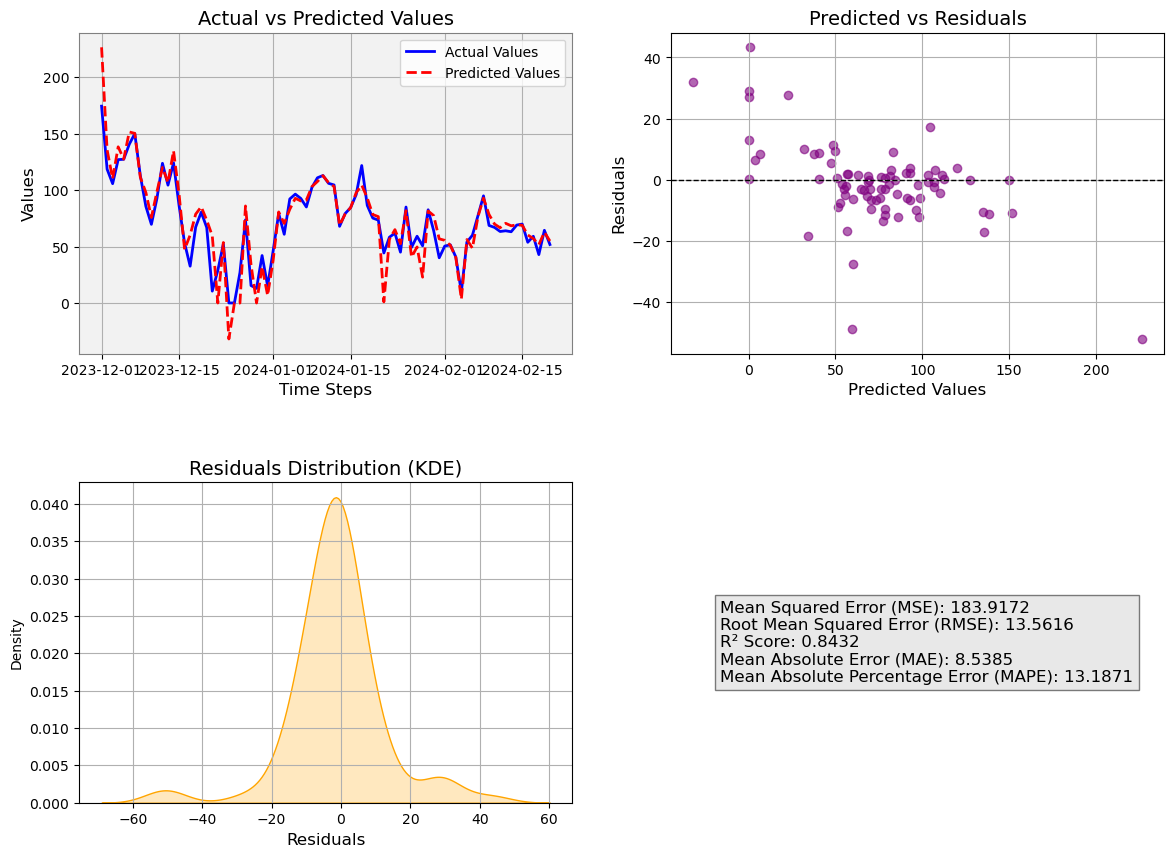

In [32]:
plot_predictions_with_metrics(test.loc[:, selected_hour], test_f.loc[:, selected_hour])

## Baseline
One hour tomorrow from all hours today

In [26]:
import lightgbm as lgbm

In [33]:
X_train = train
y_train = roll_date(train.loc[:, selected_hour], day=-1).iloc[:, 0]

X_test = test
y_test = roll_date(test.loc[:, selected_hour], day=-1).iloc[:, 0]

In [63]:
lgbm_model = lgbm.LGBMRegressor(n_estimators=6000, random_state=42, verbosity=-1)

In [35]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000353 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6070
[LightGBM] [Info] Number of data points in the train set: 759, number of used features: 24
[LightGBM] [Info] Start training from score 127.863702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMRegressor(n_estimators=6000, random_state=42)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


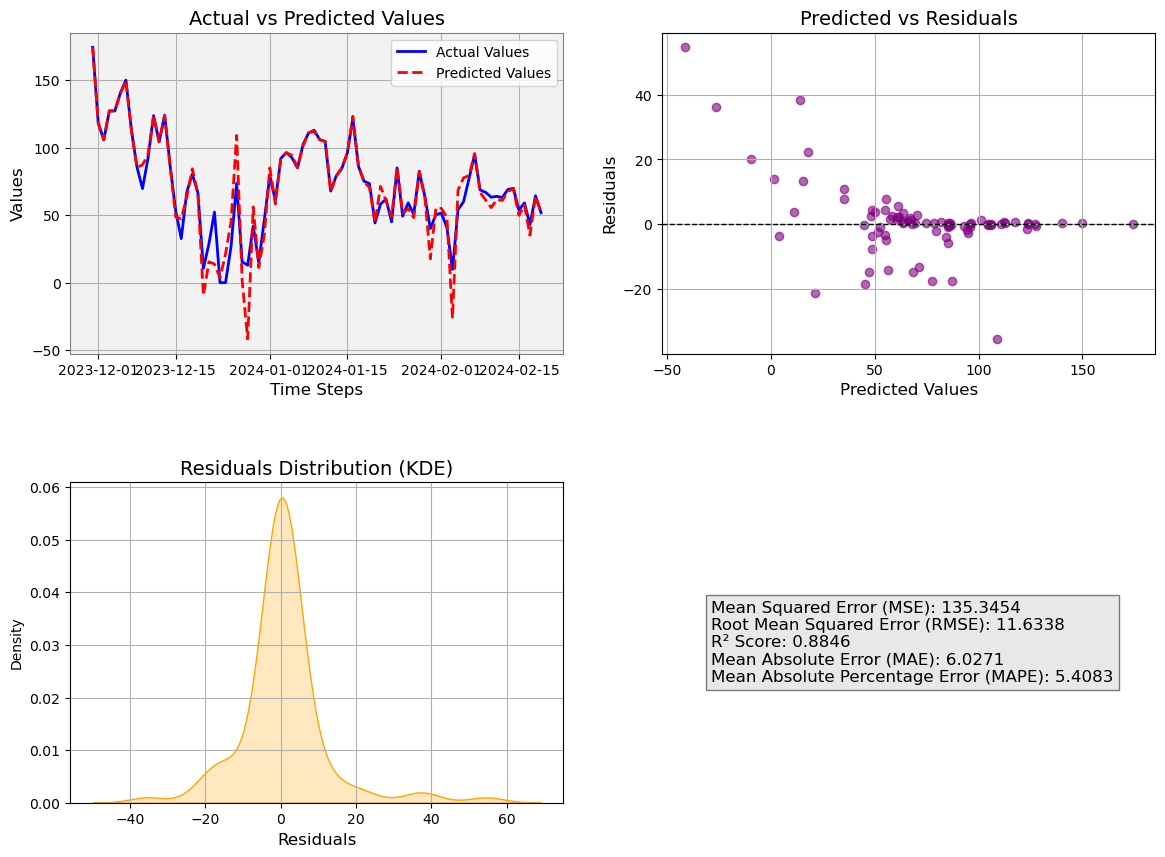

In [37]:
plot_predictions_with_metrics(y_test, pd.Series(lgbm_model.predict(X_test), index=y_test.index))

In [41]:
import shap

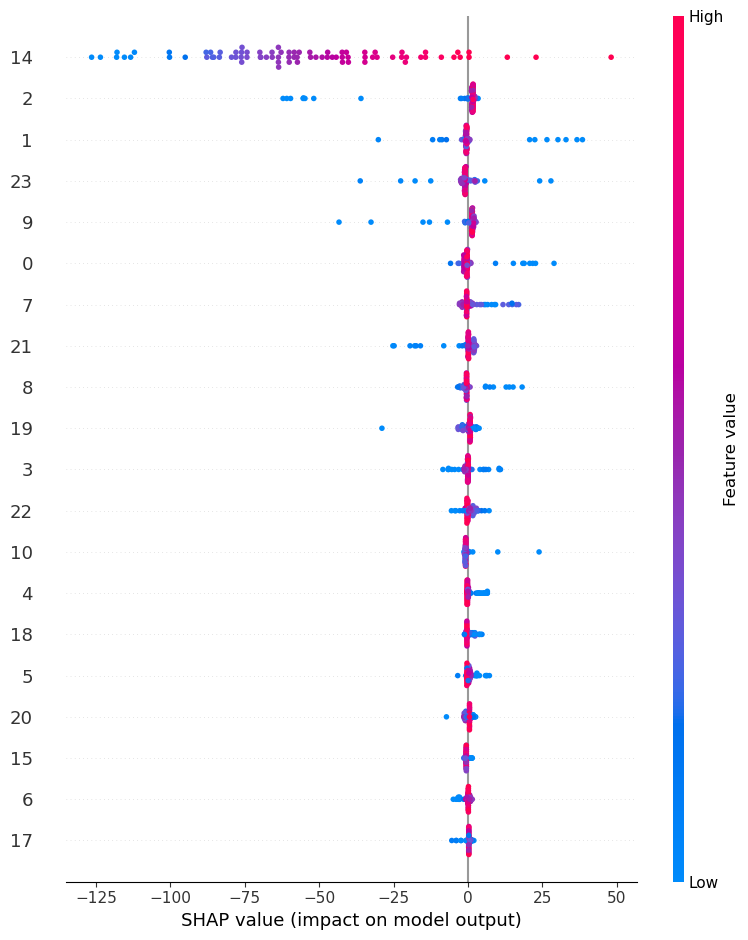

In [45]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# Plot the shap values
shap.summary_plot(shap_values, X_test)

## With Forecast
One hour tomorrow from all hours today

In [50]:
ttrain = train.join(train_f, rsuffix='f')
ttest = test.join(test_f, rsuffix='f')

In [57]:
X_train = ttrain
y_train = roll_date(ttrain.loc[:, str(selected_hour)], day=-1).iloc[:, 0]

X_test = ttest
y_test = roll_date(ttest.loc[:, str(selected_hour)], day=-1).iloc[:, 0]

In [58]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12101
[LightGBM] [Info] Number of data points in the train set: 759, number of used features: 48
[LightGBM] [Info] Start training from score 127.863702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMRegressor(n_estimators=6000, random_state=42)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


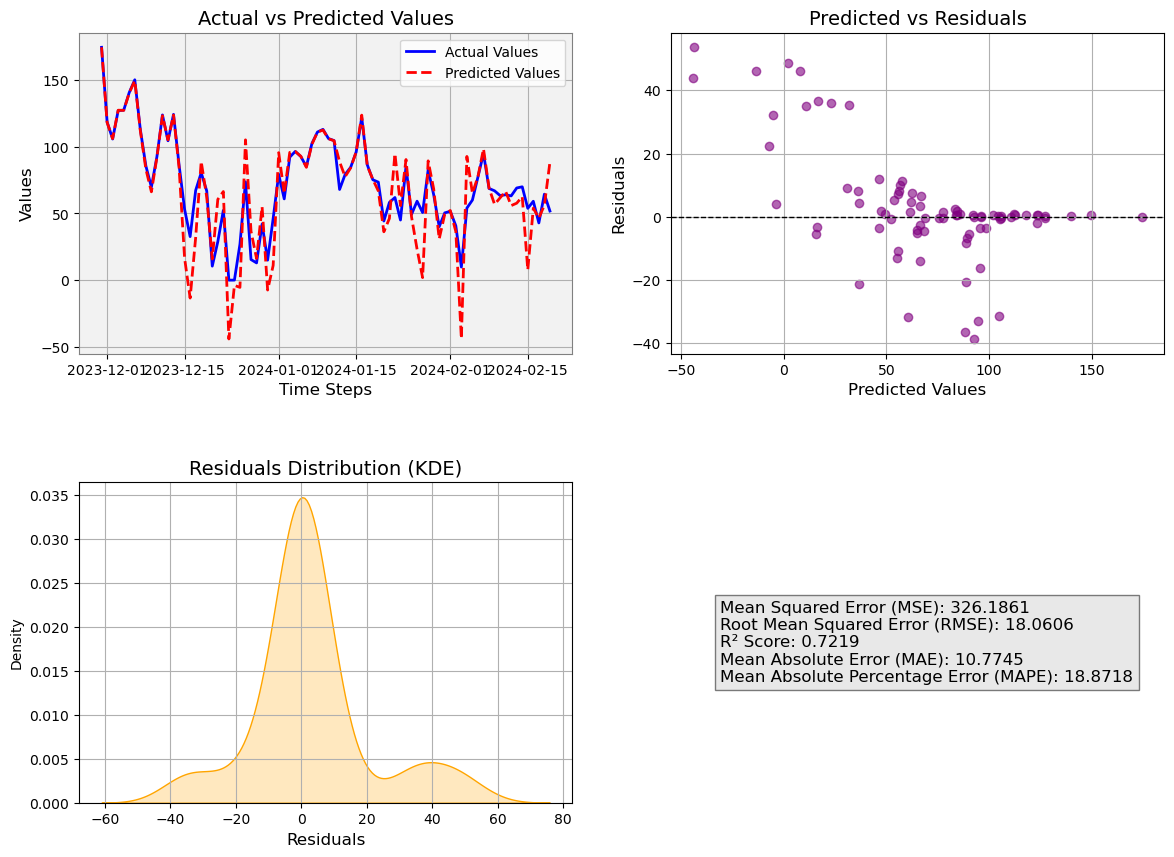

In [59]:
plot_predictions_with_metrics(y_test, pd.Series(lgbm_model.predict(X_test), index=y_test.index))

## Forecast based
w Feature selection

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

def backward_feature_elimination_with_metrics(model, X, y, cv=3):
    # Store metrics for each step of feature elimination
    feature_metrics = []
    r2 = 0

    # Start with all features
    remaining_features = list(X.columns)
    
    while len(remaining_features) > 0:
        print(f'Current Number of Featuers: {len(remaining_features)} r2 {r2}')
        # Perform cross-validation with the current set of features
        X_subset = X[remaining_features]
        model_clone = clone(model)  # Clone the model to avoid fitting the same instance multiple times
        
        # Cross-validate
        y_preds = cross_val_predict(model_clone, X_subset, y, cv=cv)

        # Calculate error metrics
        mse = mean_squared_error(y, y_preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, y_preds)
        mae = mean_absolute_error(y, y_preds)
        mape = mean_absolute_percentage_error(y, y_preds)

        # Store metrics
        feature_metrics.append({
            'num_features': len(remaining_features),
            'features': remaining_features.copy(),
            'mse': mse,
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'mape': mape
        })

        # Remove the least important feature (based on coefficients or feature importance)
        if hasattr(model, 'coef_'):  # For linear models
            importances = np.abs(model_clone.fit(X_subset, y).coef_)
        elif hasattr(model, 'feature_importances_'):  # For tree-based models
            importances = model_clone.fit(X_subset, y).feature_importances_
        else:
            # return model_clone
            raise ValueError("Model must have either 'coef_' or 'feature_importances_' attribute.")
            

        least_important_feature = remaining_features[np.argmin(importances)]
        remaining_features.remove(least_important_feature)

    # Convert the feature_metrics to a DataFrame for better readability
    metrics_df = pd.DataFrame(feature_metrics)
    return metrics_df

In [81]:
lgbm_model.fit(X_train, y_train)

LGBMRegressor(n_estimators=6000, random_state=42, verbosity=-1)

In [82]:
metrics_df = backward_feature_elimination_with_metrics(lgbm_model, X_train, y_train)

Current Number of Featuers: 48 r2 0
Current Number of Featuers: 47 r2 0.8701964339407503
Current Number of Featuers: 46 r2 0.8689512177727086
Current Number of Featuers: 45 r2 0.8683713234829316
Current Number of Featuers: 44 r2 0.8684284349113871
Current Number of Featuers: 43 r2 0.8688953320432327
Current Number of Featuers: 42 r2 0.8691307878178163
Current Number of Featuers: 41 r2 0.868537044048417
Current Number of Featuers: 40 r2 0.8685596444951564
Current Number of Featuers: 39 r2 0.8688172293435374
Current Number of Featuers: 38 r2 0.868598314524788
Current Number of Featuers: 37 r2 0.8689685085742886
Current Number of Featuers: 36 r2 0.8689642053981947
Current Number of Featuers: 35 r2 0.8685077737027302
Current Number of Featuers: 34 r2 0.8680507668333629
Current Number of Featuers: 33 r2 0.8675688726114428
Current Number of Featuers: 32 r2 0.8675704226672414
Current Number of Featuers: 31 r2 0.8675828403133075
Current Number of Featuers: 30 r2 0.8683988137857832
Current Numb

In [88]:
metrics_df.loc[metrics_df.num_features == 19, 'features'].values[0]

['2',
 '6',
 '9',
 '11',
 '14',
 '15',
 '17',
 '19',
 '21',
 '23',
 '2f',
 '6f',
 '8f',
 '13f',
 '15f',
 '16f',
 '17f',
 '19f',
 '23f']

In [91]:
ttrain = train.join(train_f, rsuffix='f')
ttest = test.join(test_f, rsuffix='f')

ttrain = ttrain[metrics_df.loc[metrics_df.num_features == 19, 'features'].values[0]]
ttest = ttest[metrics_df.loc[metrics_df.num_features == 19, 'features'].values[0]]

X_train = ttrain
y_train = roll_date(ttrain.loc[:, str(selected_hour)], day=-1).iloc[:, 0]

X_test = ttest
y_test = roll_date(ttest.loc[:, str(selected_hour)], day=-1).iloc[:, 0]

In [92]:
lgbm_model.fit(X_train, y_train)

LGBMRegressor(n_estimators=6000, random_state=42, verbosity=-1)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


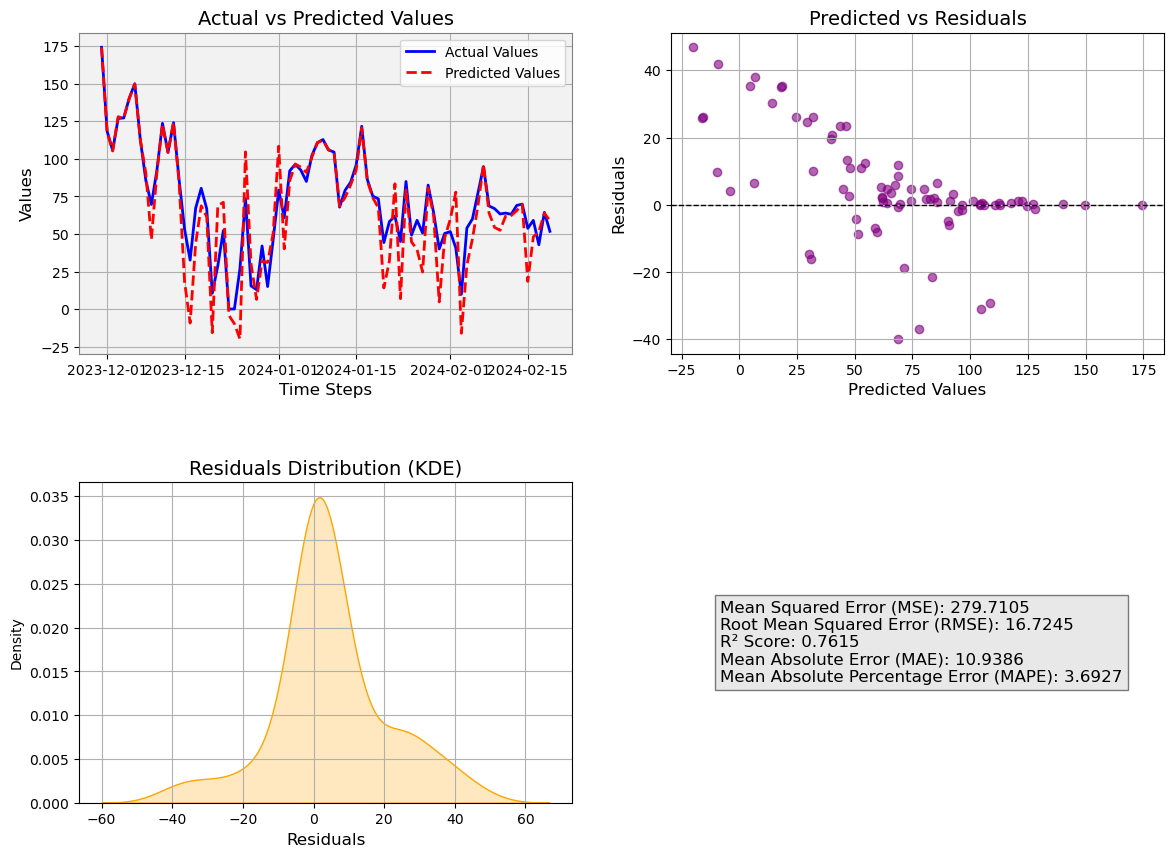

In [93]:
plot_predictions_with_metrics(y_test, pd.Series(lgbm_model.predict(X_test), index=y_test.index))

## Grand

In [118]:
def calculate_macd(price_series, slow=26, fast=12, signal=9):
    """
    Calculate MACD, Signal Line and MACD Histogram for a given price series.

    Parameters:
    price_series (pd.Series): A pandas Series representing the price data (e.g., closing prices).
    slow (int): The period for the slow EMA. Default is 26.
    fast (int): The period for the fast EMA. Default is 12.
    signal (int): The period for the signal line EMA. Default is 9.

    Returns:
    pd.DataFrame: A DataFrame containing the MACD line, Signal line, and MACD Histogram.
    """
    # Calculate the Fast and Slow EMAs
    ema_fast = price_series.ewm(span=fast, adjust=False).mean()
    ema_slow = price_series.ewm(span=slow, adjust=False).mean()

    # MACD Line: Fast EMA - Slow EMA
    macd_line = ema_fast - ema_slow

    # Signal Line: EMA of MACD Line
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()

    # MACD Histogram: MACD Line - Signal Line
    macd_histogram = macd_line - signal_line

    # Combine the results into a DataFrame
    macd_df = pd.DataFrame({
        'MACD': macd_line,
        'Signal': signal_line,
        'Histogram': macd_histogram
    })

    return macd_df.loc[:, 'MACD']

In [128]:
X_train = train#.join(roll_date(train, day=1), rsuffix='_t1') 
# X_train = train.join(train.apply(lambda x:calculate_macd(x)), rsuffix='_macd')

y_train = roll_date(train.loc[:, selected_hour], day=-1).iloc[:, 0]

X_test = test#.join(roll_date(test, day=1), rsuffix='_t1') 
# X_test = test.join(test.apply(lambda x:calculate_macd(x)), rsuffix='_macd')
y_test = roll_date(test.loc[:, selected_hour], day=-1).iloc[:, 0]

In [129]:
lgbm_model = lgbm.LGBMRegressor(n_estimators=6000, random_state=42, verbosity=-1)

In [130]:
# train_lgbm_base = roll_date(train, day=1).join(roll_date(train, day=2), lsuffix='_t1', rsuffix='_t2') 
# test_lgbm_base = roll_date(test, day=1).join(roll_date(test, day=2), lsuffix='_t1', rsuffix='_t2') 

In [144]:
grand = list()
for idx, row in X_train.dropna().iterrows():
    try:
        for iidx, value in train.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value
            grand.append(row.copy())
    except KeyError:
        continue
grand = pd.concat(grand, axis=1).T

In [145]:
lgbm_model.fit(grand.drop(columns='target_value'), grand.target_value)

LGBMRegressor(n_estimators=6000, random_state=42, verbosity=-1)

In [146]:
grand_test = list()
for idx, row in X_test.dropna().iterrows():
    try:
        for iidx, value in test.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value
            grand_test.append(row.copy())
    except KeyError:
        continue
grand_test = pd.concat(grand_test, axis=1).T

In [147]:
y_pred_lgbm = pd.DataFrame(lgbm_model.predict(grand_test.drop(columns='target_value')), index=grand_test.index)
y_pred_lgbm['target_hour'] = grand_test.target_hour

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


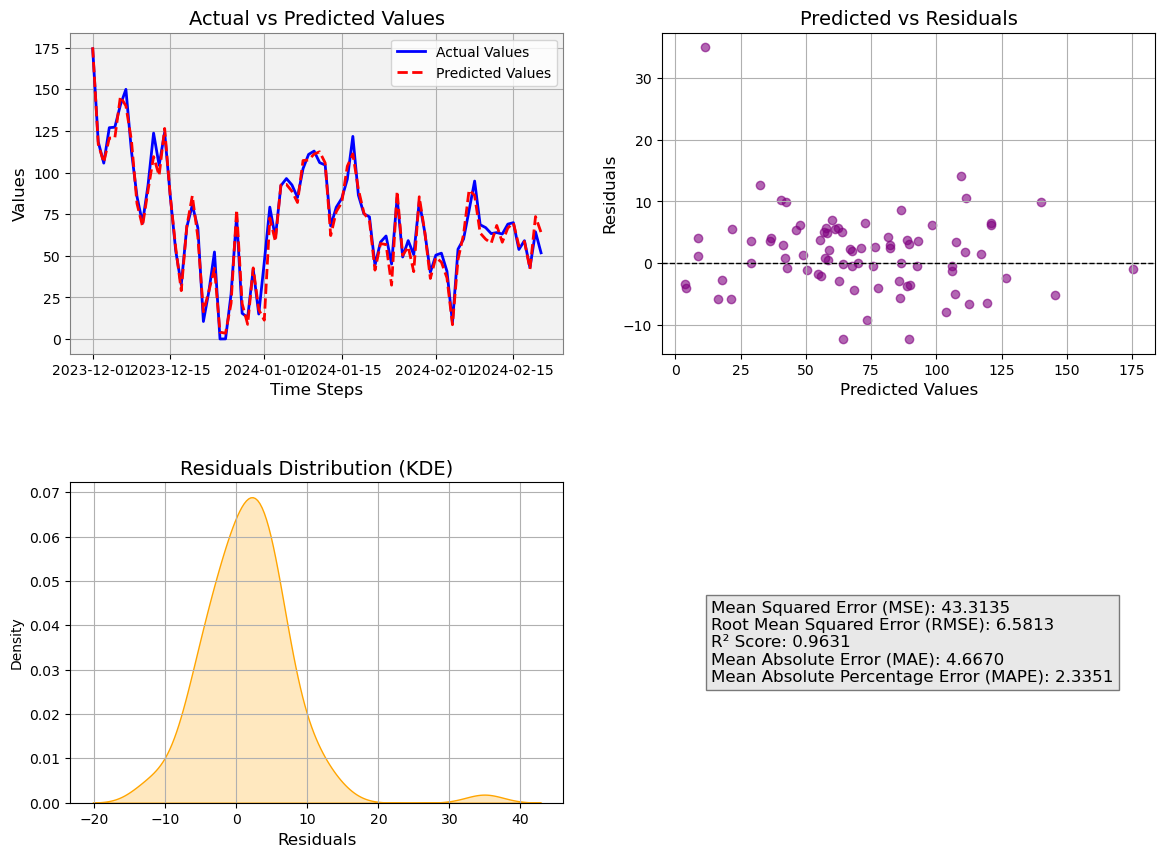

In [148]:
plot_predictions_with_metrics(grand_test.loc[grand_test.target_hour == selected_hour, 'target_value'], 
                              y_pred_lgbm.loc[y_pred_lgbm.target_hour == selected_hour][0])

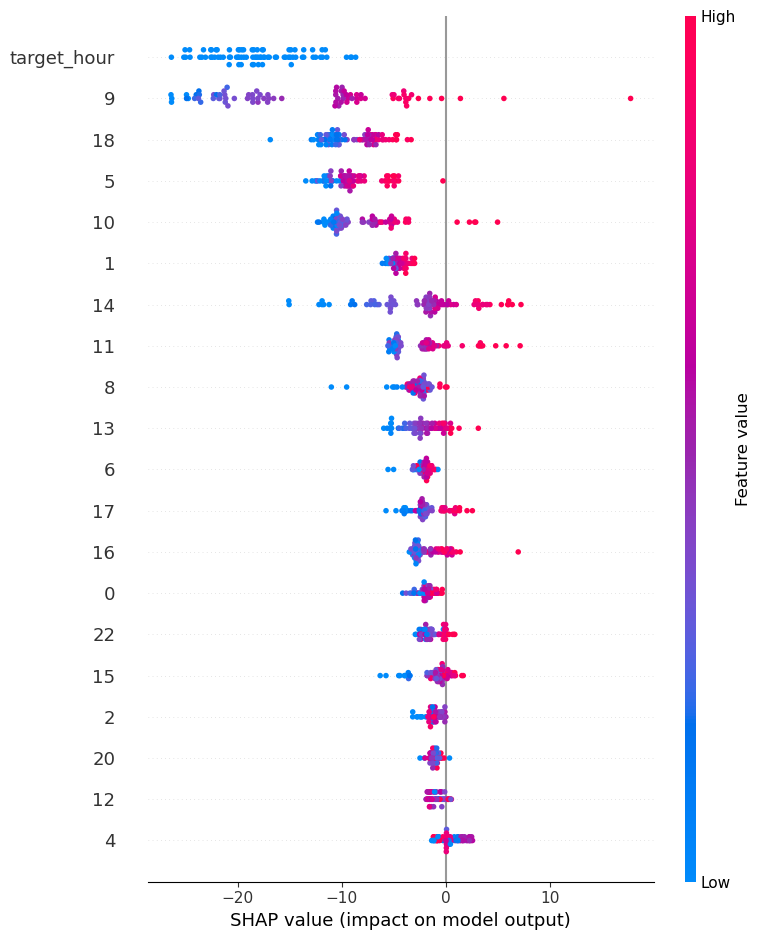

In [153]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(grand_test.loc[grand_test.target_hour == selected_hour, :].drop(columns='target_value'))

# Plot the shap values
shap.summary_plot(shap_values, grand_test.loc[grand_test.target_hour == selected_hour, :].drop(columns='target_value'))

In [136]:
metrics_df2 = backward_feature_elimination_with_metrics(lgbm_model, X_train, y_train)

Current Number of Featuers: 24 r2 0
Current Number of Featuers: 23 r2 0.8671875169545655
Current Number of Featuers: 22 r2 0.8677903755445194
Current Number of Featuers: 21 r2 0.8677990593027392
Current Number of Featuers: 20 r2 0.8685360916872136
Current Number of Featuers: 19 r2 0.8679917827669721
Current Number of Featuers: 18 r2 0.8683492708981267
Current Number of Featuers: 17 r2 0.8668850420509924
Current Number of Featuers: 16 r2 0.8666128407603308
Current Number of Featuers: 15 r2 0.8532406148400502
Current Number of Featuers: 14 r2 0.8466214835312181
Current Number of Featuers: 13 r2 0.8507798786318173
Current Number of Featuers: 12 r2 0.8495115612655993
Current Number of Featuers: 11 r2 0.8513725955432498
Current Number of Featuers: 10 r2 0.8504770882734809
Current Number of Featuers: 9 r2 0.8550872702377441
Current Number of Featuers: 8 r2 0.857774837031835
Current Number of Featuers: 7 r2 0.8546512041256368
Current Number of Featuers: 6 r2 0.8576771072475224
Current Number 

In [137]:
metrics_df2

,num_features,features,mse,rmse,r2,mae,mape
0,24,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",1796.428647,42.384297,0.867188,15.350380,1.800315e+13
1,23,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...",1788.274350,42.287993,0.867790,15.308631,1.795717e+13
2,22,"[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15...",1788.156893,42.286604,0.867799,15.265673,1.824509e+13
3,21,"[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16...",1778.187754,42.168564,0.868536,15.157011,2.118344e+13
4,20,"[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16...",1785.550105,42.255770,0.867992,15.298704,2.144580e+13
5,19,"[0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16, 1...",1780.714702,42.198515,0.868349,15.206961,2.194526e+13
6,18,"[0, 1, 2, 5, 6, 7, 8, 10, 11, 14, 15, 16, 17, ...",1800.519939,42.432534,0.866885,15.377657,2.251077e+13
7,17,"[0, 1, 2, 5, 6, 7, 8, 10, 11, 14, 15, 17, 18, ...",1804.201748,42.475896,0.866613,15.346210,1.948793e+13
8,16,"[0, 1, 2, 5, 6, 7, 8, 10, 14, 15, 17, 18, 19, ...",1985.075180,44.554183,0.853241,15.931536,1.446681e+13
9,15,"[0, 1, 2, 5, 6, 7, 8, 10, 14, 15, 17, 18, 19, ...",2074.605899,45.547842,0.846621,16.091173,1.206038e+13


## Basic LSTM

In [138]:
from sklearn.preprocessing import MinMaxScaler

In [139]:
def create_vanilla_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(120, activation='relu', input_shape=input_shape))
    model.add(Dense(24))
    model.compile(optimizer='adam', loss='mse')
    return model

In [140]:
X_train.shape

(759, 24)

In [284]:
# scaler = MinMaxScaler()
# train_scaled = scaler.fit_transform(train)
# test_scaled = scaler.transform(test)

# train_scaled = pd.DataFrame(train_scaled, index=train.index, columns=train.columns)
# test_scaled = pd.DataFrame(test_scaled, index=test.index, columns=test.columns)

# X_train, y_train = create_sequences(train_scaled, 7)
# X_test, y_test = create_sequences(test_scaled, 7)

In [141]:
X_train, y_train = create_sequences(train.fillna(0), 7)
X_test, y_test = create_sequences(test.fillna(0), 7)

NameError: name 'create_sequences' is not defined

In [286]:
X_train[np.isnan(X_train)] = 0

In [287]:
input_shape = (X_train.shape[1], X_train.shape[2])
vlstm_model = create_vanilla_lstm_model(input_shape)

In [288]:
vlstm_model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_31 (LSTM)              (None, 120)               69600     
                                                                 
 dense_28 (Dense)            (None, 24)                2904      
                                                                 
Total params: 72504 (283.22 KB)
Trainable params: 72504 (283.22 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [289]:
vlstm_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
24/24 [==============================] - 1s 3ms/step - loss: 34081.0117
Epoch 2/20
24/24 [==============================] - 0s 3ms/step - loss: 17696.9062
Epoch 3/20
24/24 [==============================] - 0s 3ms/step - loss: 9974.2842
Epoch 4/20
24/24 [==============================] - 0s 3ms/step - loss: 7421.4194
Epoch 5/20
24/24 [==============================] - 0s 3ms/step - loss: 6421.1396
Epoch 6/20
24/24 [==============================] - 0s 3ms/step - loss: 5915.2871
Epoch 7/20
24/24 [==============================] - 0s 3ms/step - loss: 5848.8013
Epoch 8/20
24/24 [==============================] - 0s 3ms/step - loss: 5732.2812
Epoch 9/20
24/24 [==============================] - 0s 3ms/step - loss: 5190.2354
Epoch 10/20
24/24 [==============================] - 0s 3ms/step - loss: 4754.6914
Epoch 11/20
24/24 [==============================] - 0s 3ms/step - loss: 4636.4028
Epoch 12/20
24/24 [==============================] - 0s 3ms/step - loss: 4459.4326
Epoch 13/20

In [313]:
y_preds = vlstm_model.predict(X_test)

3/3 [==============================] - 0s 3ms/step


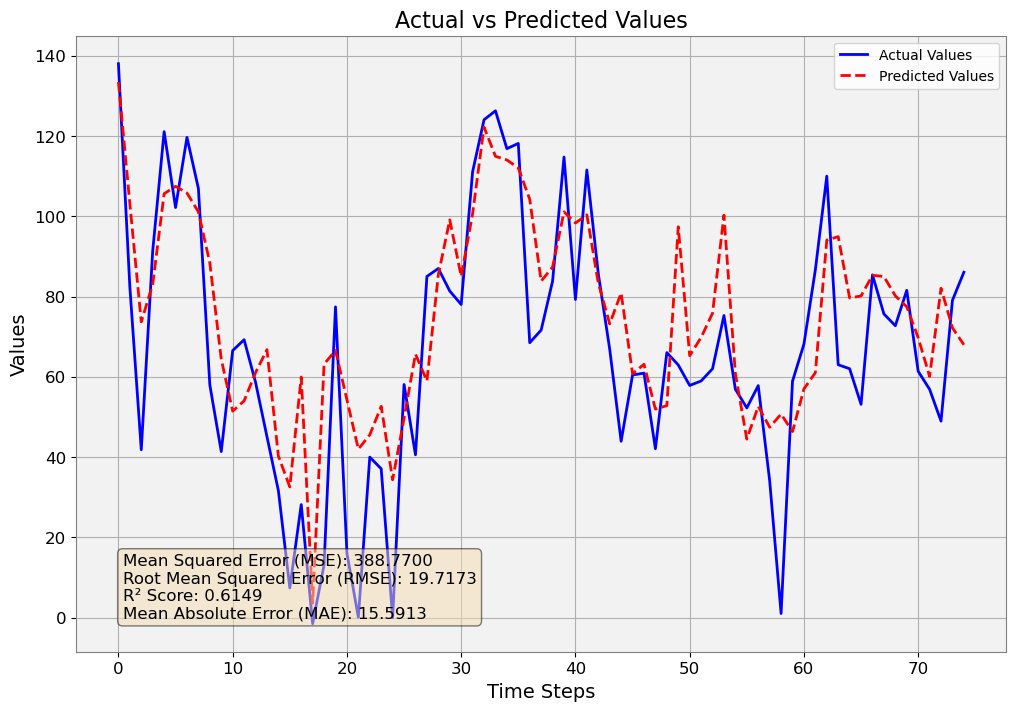

In [314]:
plot_predictions_with_metrics(y_test[:, 7], y_preds[:, 7])

In [315]:
y_train_preds = vlstm_model.predict(X_train)

24/24 [==============================] - 0s 2ms/step


In [316]:
grand2 = list()
for iii, (idx, row) in enumerate(train[lookback:].dropna().iterrows()):
    try:
        for iidx, value in train.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value - y_train_preds[iii, iidx] # 
            grand2.append(row.copy())
    except KeyError:
        continue
grand2 = pd.concat(grand2, axis=1).T

In [317]:
lgbm_residual_model = lgbm.LGBMRegressor(n_estimators=500, random_state=42)
lgbm_residual_model.fit(grand2.drop(columns='target_value'), grand2.target_value)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6144
[LightGBM] [Info] Number of data points in the train set: 17952, number of used features: 25
[LightGBM] [Info] Start training from score 2.580840


LGBMRegressor(n_estimators=500, random_state=42)

In [318]:
y_preds_component_1 = vlstm_model.predict(X_test)

3/3 [==============================] - 0s 2ms/step


In [319]:
grand_test2 = list()
#for idx, row in test_lgbm_base.dropna().iterrows():
for iii, (idx, row) in enumerate(test[lookback:].dropna().iterrows()):
    try:
        for iidx, value in test.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value - y_preds_component_1[iii, iidx]
            grand_test2.append(row.copy())
    except KeyError:
        continue
grand_test2 = pd.concat(grand_test2, axis=1).T

In [320]:
y_pred_residual_lgbm = pd.DataFrame(lgbm_residual_model.predict(grand_test2.drop(columns='target_value')), index=grand_test2.index)
y_pred_residual_lgbm['target_hour'] = grand_test2.target_hour

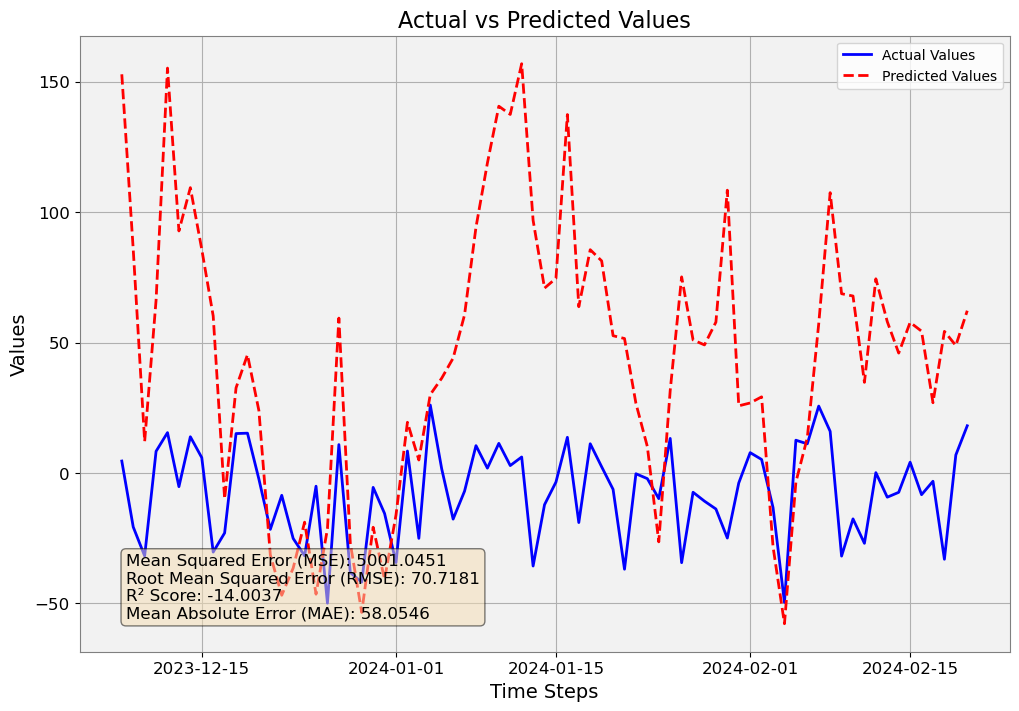

In [321]:
plot_predictions_with_metrics(grand_test2.loc[grand_test2.target_hour == 7, 'target_value'], 
                              y_pred_residual_lgbm.loc[y_pred_residual_lgbm.target_hour == 7][0] + y_preds[:, 7])

## LSTM attention

In [322]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Activation, Reshape, Permute, RepeatVector, Multiply, Lambda, Dropout, Layer
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanAbsoluteError
from keras.layers import Dense, Flatten, Embedding, Bidirectional # CuDNNLSTM
import tensorflow.keras.backend as K
# from keras import Layer
from keras import initializers, regularizers, constraints
from keras import backend as K
from tensorflow.keras.optimizers import RMSprop, Adam, Nadam, SGD
from keras import initializers, regularizers, constraints
from keras import backend as K
from keras.layers import Layer, Input, Bidirectional, LSTM, Dense
from keras.models import Model
from keras.layers import BatchNormalization
# https://www.kaggle.com/qqgeogor/keras-lstm-attention-glove840b-lb-0-043

V1

In [323]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Activation, Reshape, Permute, RepeatVector, Multiply, Lambda
from tensorflow.keras.optimizers import RMSprop
import tensorflow.keras.backend as K

In [324]:
def create_network(input_shape, rnn_units=256, use_attention=True):
    """ Create the structure of the neural network """

    # Input layer for the continuous values sequence with shape (timesteps, features)
    inputs = Input(shape=input_shape)

    # LSTM layer with return_sequences=True to get the output of all timesteps
    x = LSTM(rnn_units, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    if use_attention:
        # Second LSTM layer for attention mechanism
        x = LSTM(rnn_units, return_sequences=True)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)

        # Attention mechanism
        e = Dense(1, activation='tanh')(x)
        e = Reshape([-1])(e)
        alpha = Activation('softmax')(e)

        alpha_repeated = Permute([2, 1])(RepeatVector(rnn_units)(alpha))

        c = Multiply()([x, alpha_repeated])
        c = Lambda(lambda xin: K.sum(xin, axis=1), output_shape=(rnn_units,))(c)
    else:
        # If not using attention, use a single LSTM layer output
        c = LSTM(rnn_units)(x)

    # Output layer for continuous values
    output = Dense(24, activation='linear')(c)
    
    model = Model(inputs, output)

    if use_attention:
        att_model = Model(inputs, alpha)
    else:
        att_model = None

    # Compile the model with mean squared error loss and RMSprop optimizer
    opti = RMSprop(lr=0.001)
    model.compile(loss='mse', optimizer=opti)

    return model, att_model

In [325]:
input_shape = X_train.shape[1:]  # Number of timesteps
lstm_att_model, att_model = create_network(input_shape, use_attention=True)

<Axes: >

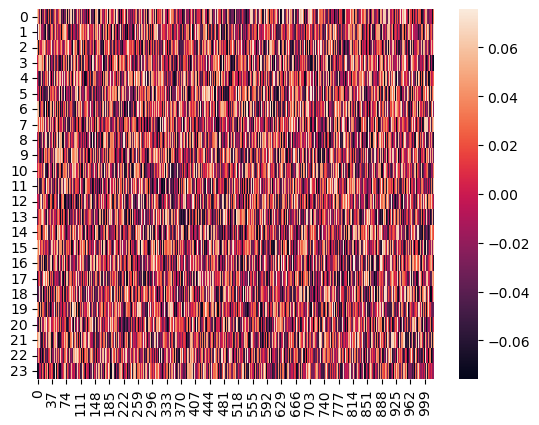

In [326]:
sns.heatmap(att_model.weights[0])

In [327]:
lstm_att_model.fit(X_train, 
          y_train, 
          epochs=20, 
          batch_size=16, 
          validation_split = 0.2, 
          shuffle=True)

Epoch 1/20
38/38 [==============================] - 5s 35ms/step - loss: 47110.9922 - val_loss: 8749.9707
Epoch 2/20
38/38 [==============================] - 0s 12ms/step - loss: 42420.2812 - val_loss: 8968.8564
Epoch 3/20
38/38 [==============================] - 0s 12ms/step - loss: 38093.5547 - val_loss: 9500.3096
Epoch 4/20
38/38 [==============================] - 0s 12ms/step - loss: 34087.6289 - val_loss: 7748.8765
Epoch 5/20
38/38 [==============================] - 0s 12ms/step - loss: 29258.2402 - val_loss: 6282.7319
Epoch 6/20
38/38 [==============================] - 0s 12ms/step - loss: 25539.0293 - val_loss: 7890.0283
Epoch 7/20
38/38 [==============================] - 0s 13ms/step - loss: 22346.5645 - val_loss: 11425.0977
Epoch 8/20
38/38 [==============================] - 0s 12ms/step - loss: 17906.4883 - val_loss: 8944.3994
Epoch 9/20
38/38 [==============================] - 0s 12ms/step - loss: 15346.1299 - val_loss: 9751.5811
Epoch 10/20
38/38 [==========================

<Axes: >

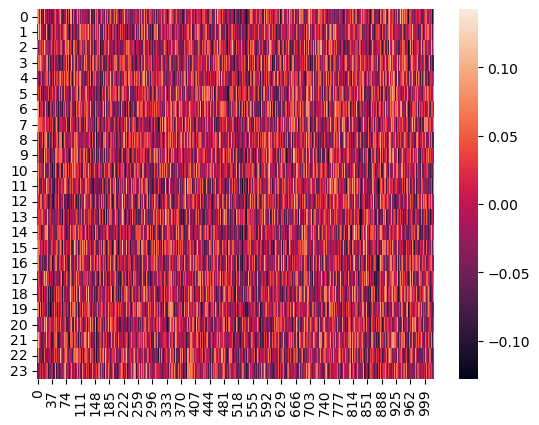

In [328]:
sns.heatmap(att_model.weights[0])

In [329]:
y_preds = lstm_att_model.predict(X_test)

3/3 [==============================] - 1s 4ms/step


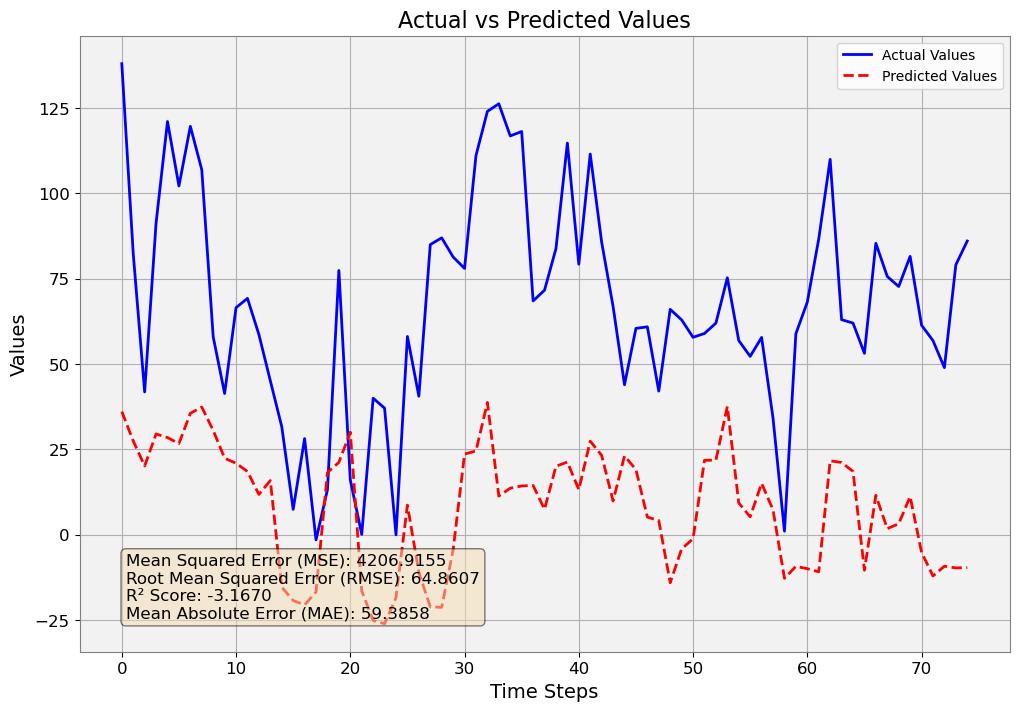

In [330]:
plot_predictions_with_metrics(y_test[:, 7], y_preds[:, 7].flatten())

## LGBM ENSEMBLE w LSTM ATTENTION RESIDUAL

In [331]:
X_train.shape

(752, 7, 24)

In [332]:
y_train_preds = lstm_att_model.predict(X_train)

24/24 [==============================] - 0s 4ms/step


In [333]:
grand2 = list()
for iii, (idx, row) in enumerate(train[lookback:].dropna().iterrows()):
    try:
        for iidx, value in train.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value - y_train_preds[iii, iidx] # 
            grand2.append(row.copy())
    except KeyError:
        continue
grand2 = pd.concat(grand2, axis=1).T

In [334]:
lgbm_residual_model = lgbm.LGBMRegressor(n_estimators=1000, random_state=42)
lgbm_residual_model.fit(grand2.drop(columns='target_value'), grand2.target_value)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6144
[LightGBM] [Info] Number of data points in the train set: 17952, number of used features: 25
[LightGBM] [Info] Start training from score 145.693037


LGBMRegressor(n_estimators=1000, random_state=42)

In [335]:
y_preds_component_1 = lstm_att_model.predict(X_test)

3/3 [==============================] - 0s 5ms/step


In [336]:
grand_test2 = list()
#for idx, row in test_lgbm_base.dropna().iterrows():
for iii, (idx, row) in enumerate(test[lookback:].dropna().iterrows()):
    try:
        for iidx, value in test.loc[idx].items():
            row['target_hour'] = iidx
            row['target_value'] = value - y_preds_component_1[iii, iidx]
            grand_test2.append(row.copy())
    except KeyError:
        continue
grand_test2 = pd.concat(grand_test2, axis=1).T

In [337]:
y_pred_residual_lgbm = pd.DataFrame(lgbm_residual_model.predict(grand_test2.drop(columns='target_value')), index=grand_test2.index)
y_pred_residual_lgbm['target_hour'] = grand_test2.target_hour

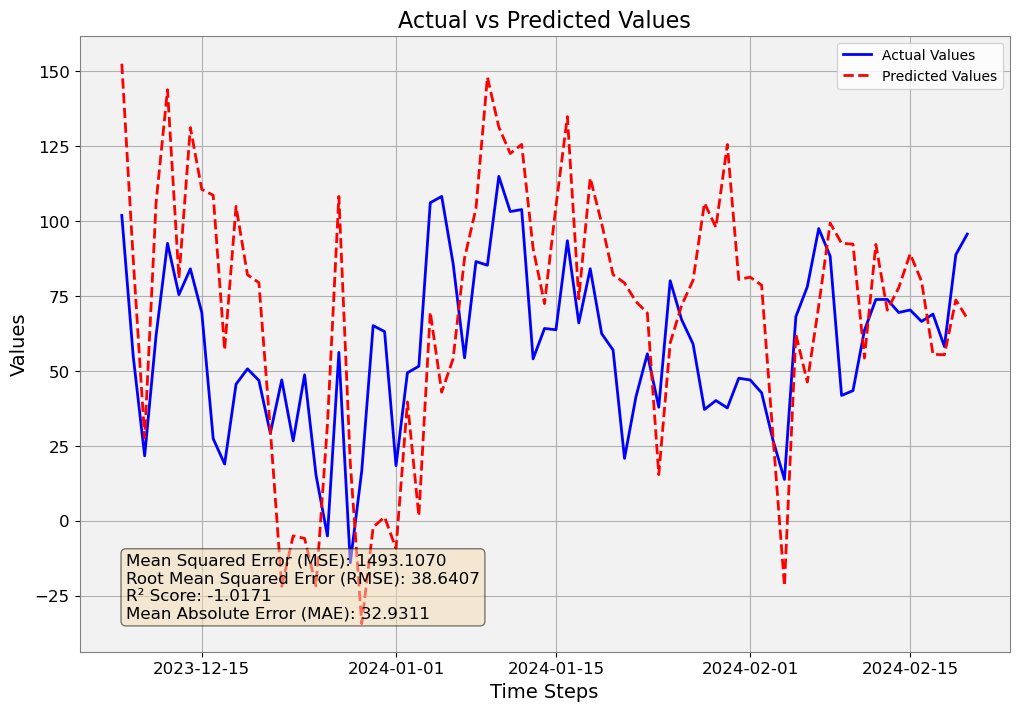

In [339]:
plot_predictions_with_metrics(grand_test2.loc[grand_test2.target_hour == 7, 'target_value'], 
                              y_pred_residual_lgbm.loc[y_pred_residual_lgbm.target_hour == 7][0] + y_preds[:, 7])

## Kaggle LSTM w Attention

In [340]:
# https://www.kaggle.com/code/aniketkolte04/optiver-2023-eda-pytorch-lstm-attention-model/notebook

In [647]:
import torch
from torch import nn
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset, random_split
import time

In [648]:
X_train.shape

(752, 7, 24)

In [649]:
class LSTMwithAttention(nn.Module):
    def __init__(self, input_size=25, hidden_layer_size=50, output_size=1, num_layers=5):
        super().__init__()

        self.input_size = input_size
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        self.batch_size = 1   

        self.conv1d = nn.Conv1d(in_channels=25, out_channels=20, kernel_size=2)
        self.lstm = nn.LSTM(20, hidden_layer_size, num_layers, dropout=0.2)

        layers = [
                nn.Linear(hidden_layer_size, hidden_layer_size),
                nn.Linear(hidden_layer_size, hidden_layer_size),
                nn.Linear(hidden_layer_size, output_size)
                ]

        self.linear_layers = nn.Sequential(*layers)

        init_rnn(self.lstm, 'xavier')
        self.dropout = nn.Dropout(0.5)
        self.attn_weights = None

    def attention_net(self, lstm_output, final_state):
        lstm_output = lstm_output.permute(1, 0, 2)
        hidden = final_state.view(-1, self.hidden_layer_size, self.num_layers)
        self.attn_weights = torch.bmm(lstm_output, hidden).squeeze(2)

        soft_attn_weights = torch.tanh(self.attn_weights)
        context = torch.bmm(lstm_output.transpose(1, 2), soft_attn_weights).squeeze(2)
        return context 

    def forward(self, input_seq):
        input_seq = input_seq.unsqueeze(0).permute(0, 2, 1)
        input_seq = self.conv1d(input_seq)
        input_seq = input_seq.permute(0, 2, 1)

        lstm_out, self.hidden_cell = self.lstm(input_seq.reshape(len(input_seq[0]), 1, 20))
        attn_output = self.attention_net(lstm_out, self.hidden_cell[0])
        
        out = self.linear_layers(attn_output.view(-1, self.hidden_layer_size))
        out = torch.tanh(out)

        return out[-1]

def init_rnn(x, type='uniform'):
    for layer in x._all_weights:
        for w in layer:
            if 'weight' in w:
                if type == 'xavier':
                    init.xavier_normal_(getattr(x, w))
                elif type == 'uniform':
                    stdv = 1.0 / (getattr(x, w).size(-1))**0.5
                    init.uniform_(getattr(x, w), -stdv, stdv)
                elif type == 'normal':
                    stdv = 1.0 / (getattr(x, w).size(-1))**0.5
                    init.normal_(getattr(x, w), 0.0, stdv)
                else:
                    raise ValueError

In [663]:
kaggle_lstm_model = LSTMwithAttention().to('cuda') # cuda

In [664]:
def train_loop(dataloader, model, loss_fn, optimizer, shortcut=0):
    size = len(dataloader.dataset)
    model.train()
    num_batches = len(dataloader)

    train_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        
        pred = model(X)
        
        # print(pred.detach().numpy().flatten())
        
        loss = loss_fn(pred, y)
        train_loss += loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if pred.std() < 0.000001:
            print("WARNING: std() is zero, stopping")
            break
        
        if shortcut > 0 and batch == shortcut:
            return train_loss.detach().cpu().numpy() / shortcut
    return train_loss.detach().cpu().numpy() / num_batches


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
      
            
            pred = model(X)
            test_loss += loss_fn(pred, y).detach().cpu().numpy()
    
        scheduler.step(test_loss)
    return test_loss / num_batches
        
def predict(X, model):
    model.eval()
    with torch.no_grad():
        pred = model(X)
    return pred.detach().cpu().numpy().flatten()

In [665]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0.00001):
        self.best_model = None
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        
    def get_best_model(self):
        return self.best_model

    def early_stop(self, validation_loss, model):
        if validation_loss < self.min_validation_loss:
            print(f"New best loss: {validation_loss:>4f}")
            self.min_validation_loss = validation_loss
            self.counter = 0
            self.best_model = model
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [666]:
optimizer = torch.optim.Adam(kaggle_lstm_model.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=8, factor=0.5, verbose=True)
early_stopper = EarlyStopper(patience=15, min_delta=0.0001)

loss_fn = nn.L1Loss()

In [667]:
means = train.mean(0)
stds = train.std(0)

In [668]:
def normalize_features(x, means=means, stds=stds):
    return (x - means) / (stds+1e-8)

# def get_xy(df):
#     x = df
#     x = normalize_features(x)
#     y = roll_date(train, day=-1)
    
#     return x.values, y.values

In [669]:
def get_xy(df):
    x = df
    x = normalize_features(x)
    y = roll_date(train, day=-1)
    grand = list()
    for iii, (idx, row) in enumerate(x.iterrows()):
        try:
            for iidx, value in y.loc[idx].items():
                # return y.loc[idx].items()
                row['hour'] = iidx
                row['target'] = value 
                grand.append(row.copy())
        except KeyError:
            continue
    grand = pd.concat(grand, axis=1).T
    
    return grand.drop(columns='target').values, grand.target.values

In [670]:
# for i in get_xy(train):
#     print(i)

In [671]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [672]:
def get_dataloaders(df, batch_size=8):
    (x,y) = get_xy(df.fillna(0))
    
    x_tensor = torch.Tensor(x).to(device)
    y_tensor = torch.Tensor(y).to(device)
    
    full_dataset = TensorDataset(x_tensor, y_tensor)
    train_dataset, test_dataset = random_split(full_dataset, [0.8,0.2])
    
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dataloader = DataLoader(test_dataset, batch_size=min(batch_size*4, len(test_dataset)), drop_last=True)
    return (train_dataloader, test_dataloader)

# train_dataloader, test_dataloader = get_dataloaders(df)
train_dataloader, test_dataloader = get_dataloaders(train)

In [673]:
for aa, bb in train_dataloader:
    break

aa.shape

bb.shape

np.isnan(aa.cpu()).any()

# kaggle_lstm_model(aa.reshape(1, 25, 8))
kaggle_lstm_model(aa)

tensor([-0.0244], device='cuda:0', grad_fn=<SelectBackward0>)

In [674]:
history = pd.DataFrame([], columns=["epoch","train_loss","test_loss","lr"])

t1 = time.time()

for epoch in range(20):
    
    print(f"Epoch {epoch+1:>3d}",end=" ")
    train_loss = train_loop(train_dataloader, kaggle_lstm_model, loss_fn, optimizer, shortcut=0)
    print(f"Train: {train_loss:>5f}", end=" ")
    test_loss = test_loop(test_dataloader, kaggle_lstm_model, loss_fn)
    print(f"| Test: {test_loss:>5f}")

    if early_stopper.early_stop(test_loss, kaggle_lstm_model) or time.time() - t1 > 60*60*8:  
        model = early_stopper.get_best_model()
        break

    history.loc[len(history),:] = [epoch+1, train_loss, test_loss, optimizer.param_groups[0]['lr']]
history

Epoch   1 

C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Train:   nan | Test:   nan
Epoch   2 

C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Train:   nan | Test:   nan
Epoch   3 

C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)

KeyboardInterrupt



In [104]:
import sklearn

In [105]:
scaler = sklearn.preprocessing.MinMaxScaler()

In [119]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
# Example usage:
input_shape = 10  # Number of timesteps
model, att_model = create_network(input_shape, use_attention=True)

In [121]:
model.fit(X_train_scaled, 
          y_train, 
          epochs=10, 
          batch_size=32, 
          validation_split = 0.2, 
          shuffle=True)

Epoch 1/10
56/56 [==============================] - 4s 29ms/step - loss: 23.9304 - val_loss: 202.0370
Epoch 2/10
56/56 [==============================] - 1s 18ms/step - loss: 11.8519 - val_loss: 171.9470
Epoch 3/10
56/56 [==============================] - 1s 18ms/step - loss: 8.8097 - val_loss: 134.9525
Epoch 4/10
56/56 [==============================] - 1s 17ms/step - loss: 7.9936 - val_loss: 102.9636
Epoch 5/10
56/56 [==============================] - 1s 17ms/step - loss: 7.6679 - val_loss: 74.1667
Epoch 6/10
56/56 [==============================] - 1s 17ms/step - loss: 7.5560 - val_loss: 60.3563
Epoch 7/10
56/56 [==============================] - 1s 17ms/step - loss: 7.5752 - val_loss: 45.9995
Epoch 8/10
56/56 [==============================] - 1s 17ms/step - loss: 6.9405 - val_loss: 38.6086
Epoch 9/10
56/56 [==============================] - 1s 17ms/step - loss: 6.5791 - val_loss: 20.5919
Epoch 10/10
56/56 [==============================] - 1s 17ms/step - loss: 6.6023 - val_loss: 1

In [122]:
y_preds = model.predict(X_test)

30/30 [==============================] - 1s 5ms/step


In [123]:
# scaler.inverse_transform(y_preds)

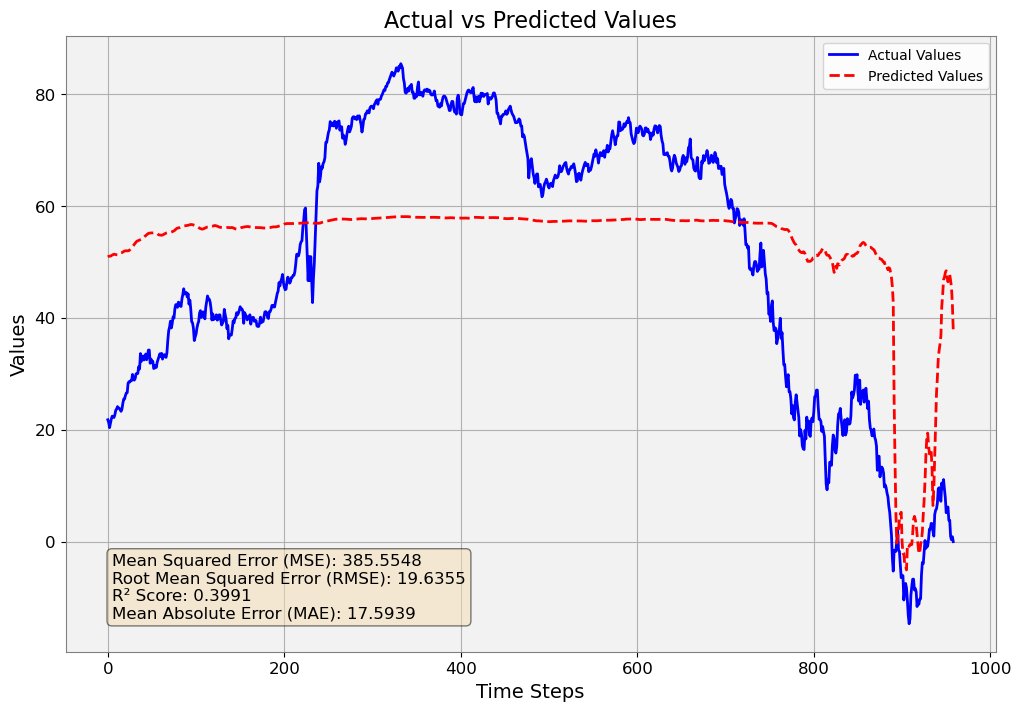

In [124]:
plot_predictions_with_metrics(y_test, y_preds)

V2

In [65]:
# https://www.kaggle.com/code/tboyle10/lstm-attention

In [75]:
class Attention(Layer):
    def __init__(self, step_dim,
                 W_regularizer=None, b_regularizer=None,
                 W_constraint=None, b_constraint=None,
                 bias=True, **kwargs):
        self.supports_masking = True
        self.init = initializers.get('glorot_uniform')

        self.W_regularizer = regularizers.get(W_regularizer)
        self.b_regularizer = regularizers.get(b_regularizer)

        self.W_constraint = constraints.get(W_constraint)
        self.b_constraint = constraints.get(b_constraint)

        self.bias = bias
        self.step_dim = step_dim
        self.features_dim = 0
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3
        self.W = self.add_weight(shape=(input_shape[-1],),
                                 initializer=self.init,
                                 regularizer=self.W_regularizer,
                                 constraint=self.W_constraint,
                                 name='{}_W'.format(self.name))
        self.features_dim = input_shape[-1]

        if self.bias:
            self.b = self.add_weight(shape=(input_shape[1],),
                                     initializer='zeros',
                                     regularizer=self.b_regularizer,
                                     constraint=self.b_constraint,
                                     name='{}_b'.format(self.name))
        else:
            self.b = None
        self.built = True

    def compute_mask(self, input, input_mask=None):
        return None

    def call(self, x, mask=None):
        features_dim = self.features_dim
        step_dim = self.step_dim
        eij = K.reshape(K.dot(K.reshape(x, (-1, features_dim)),
                        K.reshape(self.W, (features_dim, 1))), (-1, step_dim))
        if self.bias:
            eij += self.b
        eij = K.tanh(eij)
        a = K.exp(eij)
        if mask is not None:
            a *= K.cast(mask, K.floatx())
        a /= K.cast(K.sum(a, axis=1, keepdims=True) + K.epsilon(), K.floatx())
        a = K.expand_dims(a)
        weighted_input = x * a
        return K.sum(weighted_input, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape[0],  self.features_dim

In [76]:
def define_model(input_shape):
    inputs = Input(shape=(input_shape, 1))
    
    x = LSTM(128, activation='relu', return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = LSTM(64, activation='relu', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Attention(input_shape)(x)

    x = Dense(16, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=x)
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mse'])
    model.summary()
    
    return model

In [77]:
input_shape = 10
model = define_model(input_shape)  

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 10, 1)]           0         
                                                                 
 lstm_8 (LSTM)               (None, 10, 128)           66560     
                                                                 
 batch_normalization_5 (Bat  (None, 10, 128)           512       
 chNormalization)                                                
                                                                 
 dropout_5 (Dropout)         (None, 10, 128)           0         
                                                                 
 lstm_9 (LSTM)               (None, 10, 64)            49408     
                                                                 
 batch_normalization_6 (Bat  (None, 10, 64)            256       
 chNormalization)                                          

In [78]:
model.fit(X_train, 
          y_train, 
          epochs=20, 
          batch_size=32, 
          validation_split = 0.2, 
          shuffle=True)

Epoch 1/20
56/56 [==============================] - 3s 14ms/step - loss: 185.4473 - mse: 185.4473 - val_loss: 154.7217 - val_mse: 154.7217
Epoch 2/20
56/56 [==============================] - 0s 8ms/step - loss: 161.6751 - mse: 161.6751 - val_loss: 148.0142 - val_mse: 148.0142
Epoch 3/20
56/56 [==============================] - 0s 8ms/step - loss: 143.6914 - mse: 143.6914 - val_loss: 137.6955 - val_mse: 137.6955
Epoch 4/20
56/56 [==============================] - 0s 8ms/step - loss: 127.2237 - mse: 127.2237 - val_loss: 146.4370 - val_mse: 146.4370
Epoch 5/20
56/56 [==============================] - 0s 8ms/step - loss: 110.4367 - mse: 110.4367 - val_loss: 121.3109 - val_mse: 121.3109
Epoch 6/20
56/56 [==============================] - 0s 8ms/step - loss: 94.6639 - mse: 94.6639 - val_loss: 138.7108 - val_mse: 138.7108
Epoch 7/20
56/56 [==============================] - 0s 8ms/step - loss: 80.4834 - mse: 80.4834 - val_loss: 110.9273 - val_mse: 110.9273
Epoch 8/20
56/56 [===================

In [79]:
y_preds = model.predict(X_test)

30/30 [==============================] - 0s 3ms/step


In [80]:
y_preds[0,:]

array([18.786127], dtype=float32)

In [81]:
y_preds.shape

(959, 1)

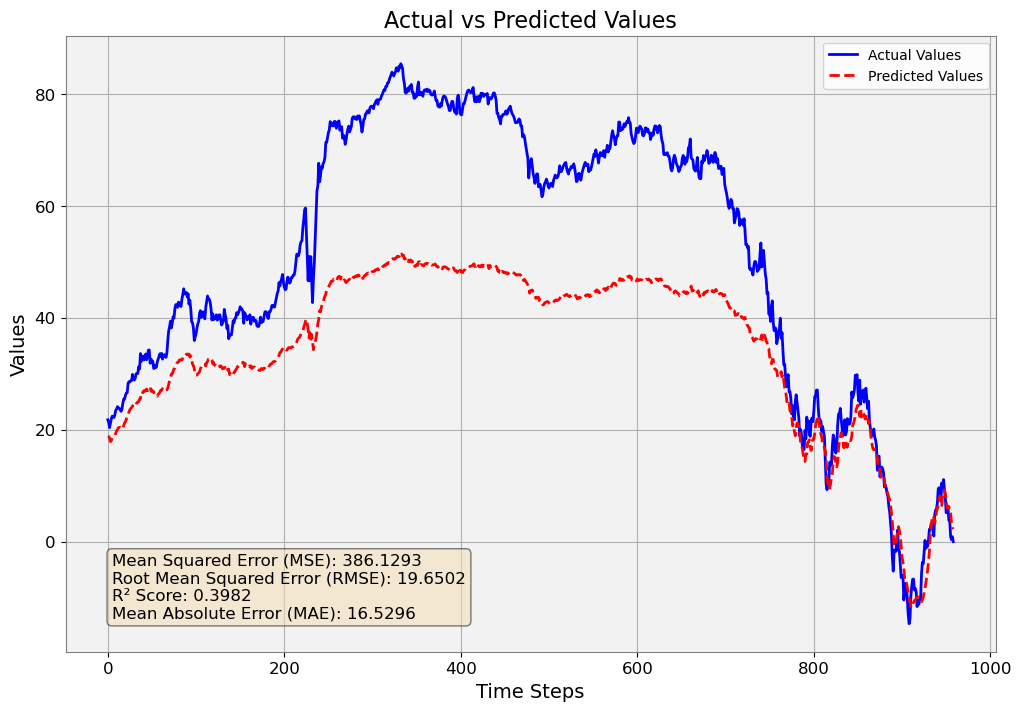

In [82]:
plot_predictions_with_metrics(y_test, y_preds)

xLSTM

In [505]:
# !pip install PyxLSTM

In [83]:
import torch
from xLSTM.model import xLSTM
# from xLSTM.data import LanguageModelingDataset, Tokenizer
# from xLSTM.utils import load_config, set_seed, get_device
# from xLSTM.training import train  # Assuming train function is defined in training module

In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super(CausalConv1D, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation, **kwargs)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super(BlockDiagonal, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_blocks = num_blocks

        assert in_features % num_blocks == 0
        assert out_features % num_blocks == 0
        
        block_in_features = in_features // num_blocks
        block_out_features = out_features // num_blocks
        
        self.blocks = nn.ModuleList([
            nn.Linear(block_in_features, block_out_features)
            for _ in range(num_blocks)
        ])
        
    def forward(self, x):
        x = x.chunk(self.num_blocks, dim=-1)
        x = [block(x_i) for block, x_i in zip(self.blocks, x)]
        x = torch.cat(x, dim=-1)
        return x

class sLSTMBlock(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads, proj_factor=4/3):
        super(sLSTMBlock, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_size = hidden_size // num_heads
        self.proj_factor = proj_factor

        assert hidden_size % num_heads == 0
        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.causal_conv = CausalConv1D(1, 1, 4)

        self.Wz = BlockDiagonal(input_size, hidden_size, num_heads)
        self.Wi = BlockDiagonal(input_size, hidden_size, num_heads)
        self.Wf = BlockDiagonal(input_size, hidden_size, num_heads)
        self.Wo = BlockDiagonal(input_size, hidden_size, num_heads)

        self.Rz = BlockDiagonal(hidden_size, hidden_size, num_heads)
        self.Ri = BlockDiagonal(hidden_size, hidden_size, num_heads)
        self.Rf = BlockDiagonal(hidden_size, hidden_size, num_heads)
        self.Ro = BlockDiagonal(hidden_size, hidden_size, num_heads)

        self.group_norm = nn.GroupNorm(num_heads, hidden_size)

        self.up_proj_left = nn.Linear(hidden_size, int(hidden_size * proj_factor))
        self.up_proj_right = nn.Linear(hidden_size, int(hidden_size * proj_factor))
        self.down_proj = nn.Linear(int(hidden_size * proj_factor), input_size)

    def forward(self, x, prev_state):
        assert x.size(-1) == self.input_size
        h_prev, c_prev, n_prev, m_prev = prev_state
        x_norm = self.layer_norm(x)
        x_conv = F.silu(self.causal_conv(x_norm.unsqueeze(1)).squeeze(1))

        z = torch.tanh(self.Wz(x) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x) + self.Ro(h_prev))
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)

        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / n_t

        output = h_t
        output_norm = self.group_norm(output)
        output_left = self.up_proj_left(output_norm)
        output_right = self.up_proj_right(output_norm)
        output_gated = F.gelu(output_right)
        output = output_left * output_gated
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)

class sLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads, num_layers=1, batch_first=False, proj_factor=4/3):
        super(sLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([sLSTMBlock(input_size, hidden_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state))
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class mLSTMBlock(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads, proj_factor=2):
        super(mLSTMBlock, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_size = hidden_size // num_heads
        self.proj_factor = proj_factor

        assert hidden_size % num_heads == 0
        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.up_proj_left = nn.Linear(input_size, int(input_size * proj_factor))
        self.up_proj_right = nn.Linear(input_size, hidden_size)
        self.down_proj = nn.Linear(hidden_size, input_size)

        self.causal_conv = CausalConv1D(1, 1, 4)
        self.skip_connection = nn.Linear(int(input_size * proj_factor), hidden_size)

        self.Wq = BlockDiagonal(int(input_size * proj_factor), hidden_size, num_heads)
        self.Wk = BlockDiagonal(int(input_size * proj_factor), hidden_size, num_heads)
        self.Wv = BlockDiagonal(int(input_size * proj_factor), hidden_size, num_heads)
        self.Wi = nn.Linear(int(input_size * proj_factor), hidden_size)
        self.Wf = nn.Linear(int(input_size * proj_factor), hidden_size)
        self.Wo = nn.Linear(int(input_size * proj_factor), hidden_size)

        self.group_norm = nn.GroupNorm(num_heads, hidden_size)

    def forward(self, x, prev_state):
        h_prev, c_prev, n_prev, m_prev = prev_state
        assert x.size(-1) == self.input_size
        x_norm = self.layer_norm(x)
        x_up_left = self.up_proj_left(x_norm)
        x_up_right = self.up_proj_right(x_norm)

        x_conv = F.silu(self.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
        x_skip = self.skip_connection(x_conv)

        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / (self.head_size ** 0.5)
        v = self.Wv(x_up_left)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up_left))

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)

        c_t = f * c_prev + i * (v * k)
        n_t = f * n_prev + i * k
        h_t = o * (c_t * q) / torch.max(torch.abs(n_t.T @ q), 1)[0]

        output = h_t
        output_norm = self.group_norm(output)
        output = output_norm + x_skip
        output = output * F.silu(x_up_right)
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)

In [85]:
import torch
import torch.nn as nn

class mLSTM(nn.Module):
    # TODO: Add bias, dropout, bidirectional
    def __init__(self, input_size, hidden_size, num_heads, num_layers=1, batch_first=False, proj_factor=2):
        super(mLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([mLSTMBlock(input_size, hidden_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state))
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class xLSTM(nn.Module):
    # TODO: Add bias, dropout, bidirectional
    def __init__(self, input_size, hidden_size, num_heads, layers, batch_first=False, proj_factor_slstm=4/3, proj_factor_mlstm=2):
        super(xLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.num_layers = len(layers)
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor_slstm
        self.proj_factor_mlstm = proj_factor_mlstm

        self.layers = nn.ModuleList()
        for layer_type in layers:
            if layer_type == 's':
                layer = sLSTMBlock(input_size, hidden_size, num_heads, proj_factor_slstm)
            elif layer_type == 'm':
                layer = mLSTMBlock(input_size, hidden_size, num_heads, proj_factor_mlstm)
            else:
                raise ValueError(f"Invalid layer type: {layer_type}. Choose 's' for sLSTM or 'm' for mLSTM.")
            self.layers.append(layer)

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state))
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state


In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [87]:
# Hyperparameters
seq_length = 10
num_sequences = 1000
input_size = 10
hidden_size = 50
num_heads = 5
num_layers = 2
batch_size = 32
learning_rate = 0.001
num_epochs = 20

In [88]:
# # Generate data
# X, y = generate_sequence_data(seq_length, num_sequences)
# X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # Shape: (num_sequences, seq_length, input_size)
# y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # Shape: (num_sequences, seq_length, input_size)

In [89]:
X_train_ = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # Shape: (num_sequences, seq_length, input_size)
y_train_ = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1) 

In [90]:
# Dataset and DataLoader
dataset = torch.utils.data.TensorDataset(X_train_, y_train_)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [91]:
# Define the xLSTM model
class SequenceModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads, num_layers):
        super(SequenceModel, self).__init__()
        self.xlstm = xLSTM(input_size, hidden_size, num_heads, ['s', 'm'], batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, state=None):
        output, state = self.xlstm(x, state)
        output = self.fc(output)
        return output, state

In [92]:
# Initialize the model, loss function, and optimizer
model = SequenceModel(input_size, hidden_size, num_heads, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [93]:
# # Training loop
# for epoch in range(num_epochs):
#     model.train()
#     for batch_x, batch_y in dataloader:
#         optimizer.zero_grad()
#         output, _ = model(batch_x)
#         loss = criterion(output, batch_y)
#         loss.backward()
#         optimizer.step()
    
#     print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

In [94]:
# # Evaluation on a sample sequence
# model.eval()
# with torch.no_grad():
#     sample_input = torch.tensor(np.sin(np.linspace(0, np.pi, seq_length)).reshape(1, -1, 1), dtype=torch.float32)
#     predicted_output, _ = model(sample_input)
#     print("Input sequence:", sample_input.squeeze().numpy())
#     print("Predicted next value:", predicted_output.squeeze().numpy())

Transformer

In [95]:
# https://towardsdatascience.com/how-to-use-transformer-networks-to-build-a-forecasting-model-297f9270e630

In [96]:
import torch
import torch.nn as nn


In [97]:
# encoder_layer = nn.TransformerEncoderLayer(
#     d_model=channels,
#     nhead=8,
#     dropout=self.dropout,
#     dim_feedforward=4 * channels,
# )
# decoder_layer = nn.TransformerDecoderLayer(
#     d_model=channels,
#     nhead=8,
#     dropout=self.dropout,
#     dim_feedforward=4 * channels,
# )

# # self.encoder = torch.nn.TransformerEncoder(encoder_layer, num_layers=8)
# # self.decoder = torch.nn.TransformerDecoder(decoder_layer, num_layers=8)

In [98]:
# https://towardsdatascience.com/how-to-use-transformer-networks-to-build-a-forecasting-model-297f9270e630
# https://www.kaggle.com/code/pankajvaluence/time-series-forecasting-lstm-fbprophet-transformer

In [99]:
import torch
import torch.nn as nn

class MyTransformerModel(nn.Module):
    def __init__(self, channels, dropout):
        super(MyTransformerModel, self).__init__()
        self.dropout = dropout
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=8,
            dropout=self.dropout,
            dim_feedforward=4 * channels,
        )
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=channels,
            nhead=8,
            dropout=self.dropout,
            dim_feedforward=4 * channels,
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=8)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=8)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, memory_mask=None):
        memory = self.encoder(src, mask=src_mask)
        output = self.decoder(tgt, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
        return output

# Example usage:
channels = 512
dropout = 0.1
model = MyTransformerModel(channels, dropout)


C:\Users\applepy\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
# <!-- https://arxiv.org/pdf/2001.08317 -->
# https://www.kaggle.com/code/pankajvaluence/time-series-forecasting-lstm-fbprophet-transformer


In [101]:
from torch import nn, Tensor

In [102]:
class PositionalEncoder(nn.Module):
    """
    Adapted from: 
    https://pytorch.org/tutorials/beginner/transformer_tutorial.html
    https://github.com/LiamMaclean216/Pytorch-Transfomer/blob/master/utils.py 
    """

    def __init__(self, dropout: float = 0.1, max_seq_len: int = 5000, d_model: int = 512):

        """
        Args:
            dropout: the dropout rate
            max_seq_len: the maximum length of the input sequences
            d_model: The dimension of the output of sub-layers in the model 
                     (Vaswani et al, 2017)
        """

        super().__init__()

        self.d_model = d_model
        
        self.dropout = nn.Dropout(p=dropout)

        # Create constant positional encoding matrix with values 
        # dependent on position and i
        position = torch.arange(max_seq_len).unsqueeze(1)
        
        exp_input = torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        
        div_term = torch.exp(exp_input) # Returns a new tensor with the exponential of the elements of exp_input
        
        pe = torch.zeros(max_seq_len, d_model)

        pe[:, 0::2] = torch.sin(position * div_term)
        
        pe[:, 1::2] = torch.cos(position * div_term) # torch.Size([target_seq_len, dim_val])

        pe = pe.unsqueeze(0).transpose(0, 1) # torch.Size([target_seq_len, input_size, dim_val])

        # register that pe is not a model parameter
        self.register_buffer('pe', pe)
        
    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: Tensor, shape [batch_size, enc_seq_len, dim_val]
        """

        add = self.pe[:x.size(1), :].squeeze(1)

        x = x + add

        return self.dropout(x)


In [103]:

class TimeSeriesTransformer(nn.Module):


    def __init__(self, 
        input_size: int,
        dec_seq_len: int,
        max_seq_len: int,
        out_seq_len: int=58,
        dim_val: int=512,  
        n_encoder_layers: int=4,
        n_decoder_layers: int=4,
        n_heads: int=8,
        dropout_encoder: float=0.2, 
        dropout_decoder: float=0.2,
        dropout_pos_enc: float=0.2,
        dim_feedforward_encoder: int=2048,
        dim_feedforward_decoder: int=2048,
        ): 

        """
        Args:
            input_size: int, number of input variables. 1 if univariate.
            dec_seq_len: int, the length of the input sequence fed to the decoder
            max_seq_len: int, length of the longest sequence the model will 
                         receive. Used in positional encoding. 
            out_seq_len: int, the length of the model's output (i.e. the target
                         sequence length)
            dim_val: int, aka d_model. All sub-layers in the model produce 
                     outputs of dimension dim_val
            n_encoder_layers: int, number of stacked encoder layers in the encoder
            n_decoder_layers: int, number of stacked encoder layers in the decoder
            n_heads: int, the number of attention heads (aka parallel attention layers)
            dropout_encoder: float, the dropout rate of the encoder
            dropout_decoder: float, the dropout rate of the decoder
            dropout_pos_enc: float, the dropout rate of the positional encoder
            dim_feedforward_encoder: int, number of neurons in the linear layer 
                                     of the encoder
            dim_feedforward_decoder: int, number of neurons in the linear layer 
                                     of the decoder
        """

        super().__init__() 

        self.dec_seq_len = dec_seq_len
#         self.pe = PositionalEncoder()

        print("input_size is: {}".format(input_size))
        print("dim_val is: {}".format(dim_val))

        # Creating the three linear layers needed for the model
        self.encoder_input_layer = nn.Linear(
            in_features=input_size, 
            out_features=dim_val 
            )

        self.decoder_input_layer = nn.Linear(
            in_features=input_size, 
            out_features=dim_val 
            )  

        self.linear_mapping = nn.Linear(
            in_features=out_seq_len*dim_val,
            out_features=out_seq_len
            )

        # Create positional encoder   ###changed
        self.positional_encoding_layer = PositionalEncoder(
            d_model=dim_val,
            dropout=dropout_pos_enc,
            max_seq_len=max_seq_len
            )

        # The encoder layer used in the paper is identical to the one used by
        # Vaswani et al (2017) on which the PyTorch module is based.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim_val, 
            nhead=n_heads,
            dim_feedforward=dim_feedforward_encoder,
            dropout=dropout_encoder,
            batch_first=True
            )

        # Stack the encoder layers in nn.TransformerDecoder
        # It seems the option of passing a normalization instance is redundant
        # in my case, because nn.TransformerEncoderLayer per default normalizes
        # after each sub-layer
        # (https://github.com/pytorch/pytorch/issues/24930).
        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=n_encoder_layers, 
            norm=None
            )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=dim_val,
            nhead=n_heads,
            dim_feedforward=dim_feedforward_decoder,
            dropout=dropout_decoder,
            batch_first=True
            )

        # Stack the decoder layers in nn.TransformerDecoder
        # It seems the option of passing a normalization instance is redundant
        # in my case, because nn.TransformerDecoderLayer per default normalizes
        # after each sub-layer
        # (https://github.com/pytorch/pytorch/issues/24930).
        self.decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=n_decoder_layers, 
            norm=None
            )

    def forward(self, src: Tensor, tgt: Tensor, src_mask: Tensor=None, 
                tgt_mask: Tensor=None) -> Tensor:
        """
        Args:
            src: the encoder's output sequence. Shape: (S,E) for unbatched input, 
                 (S, N, E) if batch_first=False or (N, S, E) if 
                 batch_first=True, where S is the source sequence length, 
                 N is the batch size, and E is the feature number
            tgt: the sequence to the decoder. Shape: (T,E) for unbatched input, 
                 (T, N, E)(T,N,E) if batch_first=False or (N, T, E) if 
                 batch_first=True, where T is the target sequence length, 
                 N is the batch size, E is the feature number.
            src_mask: the mask for the src sequence to prevent the model from 
                      using data points from the target sequence
            tgt_mask: the mask for the tgt sequence to prevent the model from
                      using data points from the target sequence
        """

        # Pass throguh the input layer right before the encoder
        src = self.encoder_input_layer(src)

        # Pass through the positional encoding layer
        src = self.positional_encoding_layer(src)

        # Pass through all the stacked encoder layers in the encoder
        # Masking is only needed in the encoder if input sequences are padded
        # which they are not in this time series use case, because all my
        # input sequences are naturally of the same length. 
        # (https://github.com/huggingface/transformers/issues/4083)
        src = self.encoder(
            src=src
            )

        # Pass decoder input through decoder input layer
        decoder_output = self.decoder_input_layer(tgt)

        # Pass throguh decoder
        decoder_output = self.decoder(
            tgt=decoder_output,
            memory=src,
            tgt_mask=tgt_mask,
            memory_mask=src_mask
            )

        # Pass through the linear mapping layer
        decoder_output= self.linear_mapping(decoder_output.flatten(start_dim=1))

        return decoder_output


CNN

NBEATS

In [126]:
# !pip install nbeats-pytorch numpy torch

In [127]:
from nbeats_pytorch.model import NBeatsNet
import torch
import numpy as np

# Define hyperparameters
input_length = 30
output_length = 10
num_blocks = 3
num_layers = 4
layer_width = 256

# Initialize N-BEATS model
model = NBeatsNet(
    device='cpu',  # or 'cuda'
    stack_types=(NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK),
    forecast_length=output_length,
    backcast_length=input_length,
    thetas_dim=(4, 4),
    nb_blocks_per_stack=num_blocks,
    share_weights_in_stack=False,
    hidden_layer_units=layer_width
)

# Optimizer
optimizer = torch.optim.Adam(model.parameters())


| N-Beats
| --  Stack Generic (#0) (share_weights_in_stack=False)
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2355508098896
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2355456177552
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2353960758224
| --  Stack Generic (#1) (share_weights_in_stack=False)
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2353960796944
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2353960759568
     | -- GenericBlock(units=256, thetas_dim=4, backcast_length=30, forecast_length=10, share_thetas=False) at @2353960760720


In [142]:
def create_sequences(data, input_length, output_length):
    X, y = [], []
    for i in range(len(data) - input_length - output_length):
        X.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    return np.array(X), np.array(y)

# # Split the data into training and test sets
# train_size = int(len(time_series_data) * 0.8)
# train_data = time_series_data[:train_size]
# test_data = time_series_data[train_size:]

# # Create sequences
# X_train, y_train = create_sequences(train_data, input_length, output_length)
# X_test, y_test = create_sequences(test_data, input_length, output_length)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


NameError: name 'torch' is not defined

In [132]:
# def train_model(model, X_train, y_train, optimizer, epochs=100, batch_size=32):
#     model.train()
#     loss_fn = torch.nn.MSELoss()
#     for epoch in range(epochs):
#         permutation = torch.randperm(X_train.size()[0])
#         for i in range(0, X_train.size()[0], batch_size):
#             indices = permutation[i:i + batch_size]
#             batch_X, batch_y = X_train[indices], y_train[indices]
#             optimizer.zero_grad()
#             forecast, backcast = model(batch_X)
#             loss = loss_fn(forecast, batch_y)
#             loss.backward()
#             optimizer.step()
#         print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}')

# # Train the model
# train_model(model, X_train, y_train, optimizer)

In [146]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

def nbeats_block(input_layer, units, expansion_coefficient_dim, block_type='trend'):
    """ Create an N-BEATS block """
    x = Dense(units, activation='relu')(input_layer)
    x = Dense(units, activation='relu')(x)
    x = Dense(units, activation='relu')(x)
    x = Dense(units, activation='relu')(x)

    if block_type == 'trend':
        backcast = Dense(expansion_coefficient_dim, activation='linear')(x)
        forecast = Dense(expansion_coefficient_dim, activation='linear')(x)
    elif block_type == 'seasonality':
        backcast = Dense(expansion_coefficient_dim, activation='sigmoid')(x)
        forecast = Dense(expansion_coefficient_dim, activation='sigmoid')(x)
    else:
        raise ValueError("block_type must be either 'trend' or 'seasonality'")

    return backcast, forecast

def create_nbeats_model(input_dim, output_dim, num_blocks=3, units=256, block_type='trend'):
    """ Create the N-BEATS model """
    inputs = Input(shape=(input_dim,))
    backcast, forecast = nbeats_block(inputs, units, input_dim, block_type)

    for _ in range(num_blocks - 1):
        residual = Add()([inputs, backcast])
        backcast, block_forecast = nbeats_block(residual, units, input_dim, block_type)
        forecast = Add()([forecast, block_forecast])

    model = Model(inputs, forecast)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return model

# Example usage:
input_length = 10
output_length = 10
num_blocks = 3
units = 256

model = create_nbeats_model(input_length, output_length, num_blocks=num_blocks, units=units)

print("Model summary:")
model.summary()

# Example: Preparing data
def create_sequences(data, input_length, output_length):
    X, y = [], []
    for i in range(len(data) - input_length - output_length):
        X.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    return np.array(X), np.array(y)

time_series_data = np.random.rand(1000)  # Replace with your actual time series data

# Split the data into training and test sets
train_size = int(len(time_series_data) * 0.8)
train_data = time_series_data[:train_size]
test_data = time_series_data[train_size:]

# Create sequences
X_train, y_train = create_sequences(train_data, input_length, output_length)
X_test, y_test = create_sequences(test_data, input_length, output_length)


Model summary:
Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_10 (InputLayer)       [(None, 10)]                 0         []                            
                                                                                                  
 dense_68 (Dense)            (None, 256)                  2816      ['input_10[0][0]']            
                                                                                                  
 dense_69 (Dense)            (None, 256)                  65792     ['dense_68[0][0]']            
                                                                                                  
 dense_70 (Dense)            (None, 256)                  65792     ['dense_69[0][0]']            
                                                                            

In [147]:
# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
20/20 [==============================] - 2s 13ms/step - loss: 0.1186 - val_loss: 0.0851
Epoch 2/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0916 - val_loss: 0.0821
Epoch 3/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0876 - val_loss: 0.0822
Epoch 4/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0852 - val_loss: 0.0811
Epoch 5/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0831 - val_loss: 0.0828
Epoch 6/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0824 - val_loss: 0.0824
Epoch 7/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0813 - val_loss: 0.0821
Epoch 8/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0784 - val_loss: 0.0828
Epoch 9/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0756 - val_loss: 0.0840
Epoch 10/50
20/20 [==============================] - 0s 5ms/step - loss: 0.0744 - val_loss: 0.0842
Epoch 11/50
20/20 

6/6 [==============================] - 0s 2ms/step


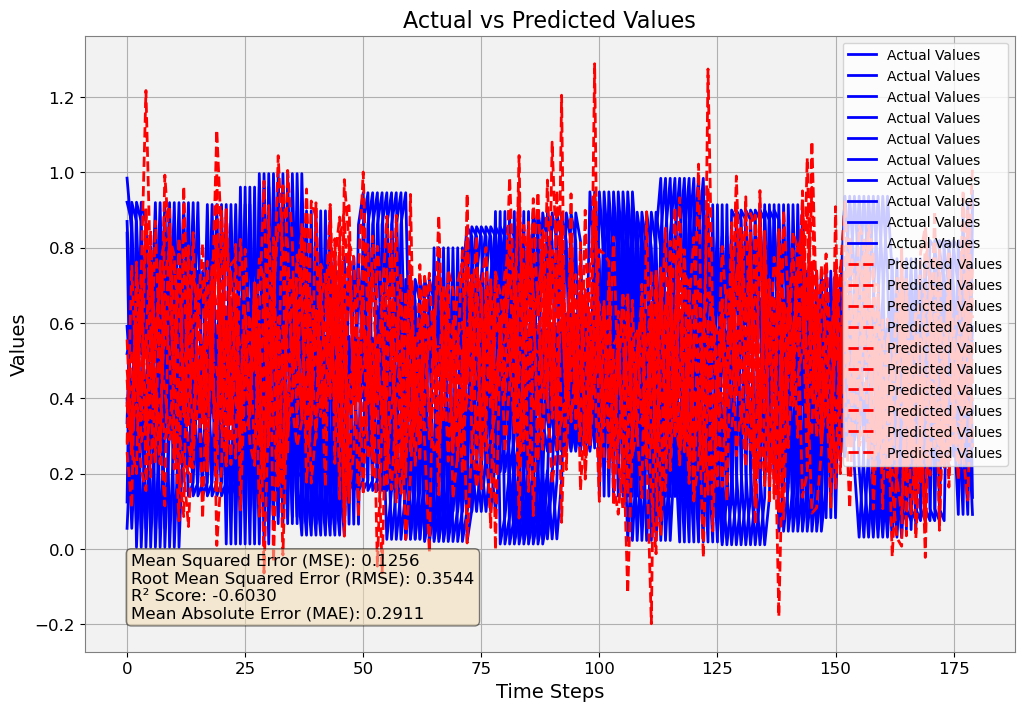

In [148]:
y_preds = model.predict(X_test)
plot_predictions_with_metrics(y_test, y_preds)

In [ ]:
# # Evaluate the model
# loss = model.evaluate(X_test, y_test)
# print(f'Test Loss: {loss}')

# # Plot predictions
# def plot_predictions(model, X_test, y_test, num_predictions=100):
#     y_preds = model.predict(X_test[:num_predictions])

#     plt.figure(figsize=(12, 6))
#     for i in range(num_predictions):
#         plt.plot(range(i, i + output_length), y_preds[i], color='red')
#         plt.plot(range(i, i + output_length), y_test[i], color='blue')
#     plt.title('N-BEATS Predictions')
#     plt.xlabel('Time Steps')
#     plt.ylabel('Values')
#     plt.legend(['Predicted', 'Actual'])
#     plt.show()

# # Plot the predictions
# plot_predictions(model, X_test, y_test)